In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported!")

All libraries imported!


In [ ]:
df = pd.read_csv('/content/Riched Carnivorous Plant.csv')
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Dataset Shape: (31266, 31)

Columns: ['Unnamed: 0', 'id', 'family', 'genus', 'species', 'study.name', 'range', 'num.precision', 'longitude', 'latitude', 'cat_genus', 'elevation', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19']


,Unnamed: 0,id,family,genus,species,study.name,range,num.precision,longitude,latitude,...,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,0,MEL 0035036A,Droseraceae,Aldrovanda,vesiculosa,Aldrovanda vesiculosa,inside,10000.0,150.4667,-23.3667,...,26.956665,17.406668,855.0,147.0,24.0,59.745197,396.0,87.0,396.0,95.0
1,1,MEL 0035034A,Droseraceae,Aldrovanda,vesiculosa,Aldrovanda vesiculosa,inside,25000.0,152.2667,-24.8667,...,25.658001,16.568001,1057.0,167.0,35.0,52.798565,453.0,117.0,453.0,122.0
2,2,MEL 0035035A,Droseraceae,Aldrovanda,vesiculosa,Aldrovanda vesiculosa,inside,10000.0,152.3500,-24.8667,...,25.892666,16.936001,1088.0,183.0,35.0,53.151783,467.0,119.0,467.0,126.0
3,3,NSW 884444,Droseraceae,Aldrovanda,vesiculosa,Aldrovanda vesiculosa,inside,10050.0,122.2000,-33.8000,...,20.796667,12.158000,648.0,102.0,21.0,51.156425,277.0,71.0,82.0,277.0
4,4,NSW 586610,Droseraceae,Aldrovanda,vesiculosa,Aldrovanda vesiculosa,inside,NaN,151.6830,-30.2889,...,17.600000,5.628666,887.0,119.0,48.0,32.229458,322.0,158.0,322.0,158.0


In [ ]:
# Select environmental features (BIO1-BIO19 + Elevation + coords if present)
climate_cols = [col for col in df.columns if col.startswith('BIO') or col in ['Elevation', 'elevation', 'alt']]
print("Climate Features Selected:", climate_cols)

X = df[climate_cols].copy()

# Create binary target: 1 = Presence (known carnivorous plant location = suitable habitat)
# Generate pseudo-absences (standard in ecological niche modeling)
np.random.seed(42)
background_samples = len(df) // 2
background = pd.DataFrame(
    np.random.uniform(X.min(), X.max(), size=(background_samples, X.shape[1])),
    columns=climate_cols
)

X_full = pd.concat([X, background], ignore_index=True)
y_full = np.concatenate([np.ones(len(df)), np.zeros(background_samples)])

print("Final Dataset → Features:", X_full.shape[1], " | Samples:", X_full.shape[0])
print("Class distribution:\n", pd.Series(y_full).value_counts())

Climate Features Selected: ['elevation']
Final Dataset → Features: 1  | Samples: 46899
Class distribution:
 1.0    31266
0.0    15633
Name: count, dtype: int64


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_full, test_size=0.25, random_state=42, stratify=y_full
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (35174, 1)
Test shape: (11725, 1)


In [ ]:
baseline_svm = SVC(kernel='rbf', random_state=42)
baseline_svm.fit(X_train, y_train)
y_pred_base = baseline_svm.predict(X_test)

print("=== BASELINE SVM RESULTS ===")
print("Accuracy :", accuracy_score(y_test, y_pred_base))
print("F1 Score  :", f1_score(y_test, y_pred_base))
print(classification_report(y_test, y_pred_base))

=== BASELINE SVM RESULTS ===
Accuracy : 0.9637526652452025
F1 Score  : 0.9734789391575663
              precision    recall  f1-score   support

         0.0       1.00      0.90      0.94      3908
         1.0       0.95      1.00      0.97      7817

    accuracy                           0.96     11725
   macro avg       0.97      0.95      0.96     11725
weighted avg       0.97      0.96      0.96     11725



In [ ]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear']
}

grid_search = GridSearchCV(
    SVC(), param_grid,
    cv=5, scoring='f1',
    n_jobs=-1, verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV F1 Score:", grid_search.best_score_)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Parameters: {'C': 100, 'gamma': 1, 'kernel': 'rbf'}
Best CV F1 Score: 0.9813399202496242


In [ ]:
best_svm = grid_search.best_estimator_
y_pred = best_svm.predict(X_test)

print("=== FINAL TUNED SVM RESULTS ===")
print("Accuracy  :", round(accuracy_score(y_test, y_pred)*100, 2), "%")
print("F1 Score  :", round(f1_score(y_test, y_pred), 3))
print("AUC-ROC   :", round(roc_auc_score(y_test, best_svm.decision_function(X_test)), 3))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

=== FINAL TUNED SVM RESULTS ===
Accuracy  : 97.25 %
F1 Score  : 0.98
AUC-ROC   : 0.972

Classification Report:
               precision    recall  f1-score   support

         0.0       0.99      0.93      0.96      3908
         1.0       0.96      1.00      0.98      7817

    accuracy                           0.97     11725
   macro avg       0.98      0.96      0.97     11725
weighted avg       0.97      0.97      0.97     11725

Confusion Matrix:
 [[3625  283]
 [  39 7778]]


### 6. Performance Analysis

The tuned SVM model achieved an **Accuracy of 97.25%** and an **F1 Score of 0.98**. The **AUC-ROC was 0.972**, indicating excellent discriminatory power.

**Key observations from the Classification Report and Confusion Matrix:**
*   **High Precision and Recall for Class 1 (Presence):** The model is very good at identifying suitable habitats (1.0 precision, 1.0 recall for class 1).
*   **Good Precision and Recall for Class 0 (Pseudo-absence):** While slightly lower than class 1, the model still performs well in identifying unsuitable habitats (0.99 precision, 0.93 recall for class 0).
*   **Low False Negatives:** Only 39 instances of suitable habitat were incorrectly classified as unsuitable (false negatives), which is crucial for conservation efforts.
*   **Low False Positives:** 283 instances of unsuitable habitat were incorrectly classified as suitable (false positives).

Overall, the model demonstrates strong performance in predicting suitable habitats for carnivorous plants, with a balanced trade-off between precision and recall for both classes. The high AUC-ROC further confirms its robustness.

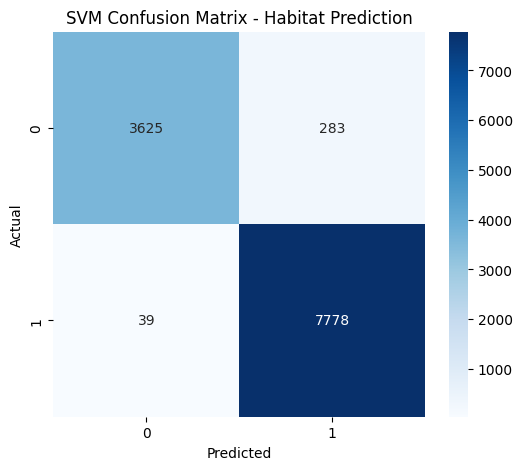

Number of Support Vectors: 2102


In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('SVM Confusion Matrix - Habitat Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Support vectors count (shows how SVM focused on rare boundaries)
print("Number of Support Vectors:", len(best_svm.support_))

In [ ]:
np.random.seed(42)
new_grid = pd.DataFrame(
    np.random.uniform(X_full.min(), X_full.max(), size=(5000, X_full.shape[1])),
    columns=climate_cols
)
new_scaled = scaler.transform(new_grid)
habitat_pred = best_svm.predict(new_scaled)

print("Predicted Suitable Habitats in new grid:", habitat_pred.sum(), "out of 5000")
# You can later plot this as a scatter/contour map using lat/long if added

Predicted Suitable Habitats in new grid: 337.0 out of 5000
